# **1) Problem Statement**

**Breast cancer** is one of the most prevalent cancers worldwide — 1 in 8 women are affected globally. Despite advances in imaging technology, the diagnosis process remains heavily dependent on manual interpretation by radiologists, which introduces several critical issues:


*   High misdiagnosis rate — approximately 30% of mammography readings result in diagnostic errors, either missing malignancies or flagging benign cases unnecessarily.

*   Radiologist fatigue — high workloads and repetitive screening tasks lead to fatigue-induced errors, especially in high-volume clinical settings.

*   Subjectivity — interpretation varies between radiologists, leading to inconsistent diagnoses for the same image.
*   Late detection — missed early-stage malignancies significantly reduce patient survival chances. Early detection raises survival rates to 85%+.

**Proposed Solution:**
An intelligent, cascaded AI pipeline — YOLO → U-Net → CNN — that assists radiologists by automating localization, segmentation, and classification of suspicious lesions in mammograms, with doctor-in-the-loop validation at each stage to ensure clinical safety and trust.

In [3]:
from google.colab import drive
import os

In [4]:
# Connect with my drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [5]:
os.chdir("/content/drive/MyDrive/")

# **2) Localization**

In [26]:
import os
import shutil
import random
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
SOURCE_ROOT = "BUSI_Jpeg"

CATEGORIES = {
    "benign": ("benign", "benign_mask"),
    "malignant": ("malignant", "malignant_mask")
}

OUTPUT_ROOT = "CancerCellDataset"

SPLIT_RATIO = {
    "train": 0.7,
    "val": 0.2,
    "test": 0.1
}

# -----------------------------
# CREATE FOLDERS
# -----------------------------
def create_folders():
    for split in ["train", "val", "test"]:
        os.makedirs(f"{OUTPUT_ROOT}/images/{split}", exist_ok=True)
        os.makedirs(f"{OUTPUT_ROOT}/masks/{split}", exist_ok=True)

# -----------------------------
# GET PAIRS (image, mask)
# -----------------------------
def get_image_mask_pairs(img_dir, mask_dir):
    pairs = []

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)

        mask_name = img_name.replace(".png", "_mask.png")
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))

    return pairs

# -----------------------------
# SPLIT DATA
# -----------------------------
def split_data(pairs):
    random.shuffle(pairs)

    n = len(pairs)
    train_end = int(n * SPLIT_RATIO["train"])
    val_end = train_end + int(n * SPLIT_RATIO["val"])

    return {
        "train": pairs[:train_end],
        "val": pairs[train_end:val_end],
        "test": pairs[val_end:]
    }

# -----------------------------
# COPY FILES
# -----------------------------
def copy_files(split_data_dict):
    for split, pairs in split_data_dict.items():
        for img_path, mask_path in pairs:

            img_name = os.path.basename(img_path)
            mask_name = os.path.basename(mask_path)

            shutil.copy(img_path, f"{OUTPUT_ROOT}/images/{split}/{img_name}")
            shutil.copy(mask_path, f"{OUTPUT_ROOT}/masks/{split}/{mask_name}")

# -----------------------------
# MAIN PIPELINE
# -----------------------------
def build_dataset():
    create_folders()

    all_pairs = []

    for label, (img_folder, mask_folder) in CATEGORIES.items():
        img_dir = os.path.join(SOURCE_ROOT, img_folder)
        mask_dir = os.path.join(SOURCE_ROOT, mask_folder)

        pairs = get_image_mask_pairs(img_dir, mask_dir)
        all_pairs.extend(pairs)

    split_dict = split_data(all_pairs)
    copy_files(split_dict)

    print("Dataset successfully created!")

# -----------------------------
# RUN
# -----------------------------
build_dataset()

Dataset successfully created!


In [27]:
import cv2
import os
import numpy as np

# Find tumor contour

def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    return max(contours, key=cv2.contourArea)


# Convert contour → bounding box

def contour_to_bbox(contour):
    x, y, w, h = cv2.boundingRect(contour)
    return x, y, w, h

# Convert to YOLO format

def bbox_to_yolo(x, y, w, h, img_w, img_h):
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm = w / img_w
    h_norm = h / img_h

    return x_center, y_center, w_norm, h_norm


# Save label to .txt file

def save_yolo_label(path, label):
    with open(path, "w") as f:
        f.write(label)

# Full pipeline function

def process_mask_to_yolo(image_path, mask_path, label_path):

    # load image + mask
    img = cv2.imread(image_path)
    mask = cv2.imread(mask_path, 0)

    img_h, img_w = img.shape[:2]

    # STEP 1: contour
    contour = get_largest_contour(mask)
    if contour is None:
        return

    # STEP 2: bbox
    x, y, w, h = contour_to_bbox(contour)

    # STEP 3: YOLO format
    xc, yc, wn, hn = bbox_to_yolo(x, y, w, h, img_w, img_h)

    # STEP 4: class = 0 (tumor only)
    label = f"0 {xc} {yc} {wn} {hn}"

    # STEP 5: save
    save_yolo_label(label_path, label)


# Process whole dataset

def generate_labels(image_dir, mask_dir, label_dir):

    os.makedirs(label_dir, exist_ok=True)

    for img_name in os.listdir(image_dir):

        if not img_name.endswith(".png"):
            continue

        image_path = os.path.join(image_dir, img_name)

        mask_name = img_name.replace(".png", "_mask.png")
        mask_path = os.path.join(mask_dir, mask_name)

        label_name = img_name.replace(".png", ".txt")
        label_path = os.path.join(label_dir, label_name)

        if os.path.exists(mask_path):
            process_mask_to_yolo(image_path, mask_path, label_path)

In [28]:
lists = ["train", "val", "test"]

for i in lists:
  generate_labels(
      image_dir = f"CancerCellDataset/images/{i}",
      mask_dir = f"CancerCellDataset/masks/{i}",
      label_dir = f"CancerCellDataset/labels/{i}"
  )

In [11]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/CancerCellDataset"
results = model.train(
    data=f"{DATASET_PATH}/data.yml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CancerCellDataset/data.yml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/runs/detect/train-4/weights/best.pt",
    "/content/drive/MyDrive/cascadedDeepLearningForCancerCellDetectionAndClassification/best_tumor_model.pt"
)

'/content/drive/MyDrive/cascadedDeepLearningForCancerCellDetectionAndClassification/best_tumor_model.pt'

In [29]:
def compute_dice(mask_pred, mask_gt, smooth=1e-6):
    mask_pred = mask_pred.astype(bool)
    mask_gt = mask_gt.astype(bool)

    intersection = np.logical_and(mask_pred, mask_gt).sum()
    dice = (2 * intersection + smooth) / (mask_pred.sum() + mask_gt.sum() + smooth)

    return dice
def box_to_mask(box, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    x1, y1, x2, y2 = map(int, box)
    mask[y1:y2, x1:x2] = 1
    return mask


In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def yolo_to_xyxy(label, img_w, img_h):
    cls, xc, yc, w, h = map(float, label.split())

    x1 = int((xc - w/2) * img_w)
    y1 = int((yc - h/2) * img_h)
    x2 = int((xc + w/2) * img_w)
    y2 = int((yc + h/2) * img_h)

    return [x1, y1, x2, y2]


def bbox_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = areaA + areaB - interArea
    if union == 0:
        return 0

    return interArea / union


In [31]:
def visualize_result(img_path, mask_path, gt_box, pred_box, save_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Overlay mask (green)
    mask_color = np.zeros_like(img_rgb)
    mask_color[:, :, 1] = mask
    overlay = cv2.addWeighted(img_rgb, 0.7, mask_color, 0.3, 0)

    # Draw GT box (green)
    cv2.rectangle(overlay, (gt_box[0], gt_box[1]), (gt_box[2], gt_box[3]), (0,255,0), 2)

    # Draw predicted box (red)
    cv2.rectangle(overlay, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255,0,0), 2)

    # DISPLAY
    plt.figure(figsize=(7,7))
    plt.imshow(overlay)
    plt.title("Green = Ground Truth, Red = Prediction")
    plt.axis("off")
    plt.show()

    # SAVE
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()


In [32]:
from ultralytics import YOLO
import glob

model = YOLO("/content/drive/MyDrive/cascadedDeepLearningForCancerCellDetectionAndClassification/best_tumor_model.pt")

test_images = sorted(glob.glob("CancerCellDataset/images/test/*.png"))

save_dir = "test_visualizations"
os.makedirs(save_dir, exist_ok=True)

ious = []
dice_scores = []

# -----------------------------
# Dice metric
# -----------------------------
def compute_dice(pred_mask, gt_mask, smooth=1e-6):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)

    intersection = (pred_mask & gt_mask).sum()
    dice = (2 * intersection + smooth) / (pred_mask.sum() + gt_mask.sum() + smooth)
    return dice

# -----------------------------
# Convert predicted box → mask
# -----------------------------
def box_to_mask(box, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    x1, y1, x2, y2 = map(int, box)
    mask[y1:y2, x1:x2] = 1
    return mask


for img_path in test_images:

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Ground truth label
    label_path = img_path.replace("images", "labels").replace(".png", ".txt")
    if not os.path.exists(label_path):
        print("Missing label:", label_path)
        continue

    with open(label_path) as f:
        gt_label = f.read().strip()

    gt_box = yolo_to_xyxy(gt_label, w, h)

    # Ground truth mask
    mask_path = img_path.replace("images", "masks").replace(".png", "_mask.png")
    if not os.path.exists(mask_path):
        print("Missing mask:", mask_path)
        continue

    gt_mask = cv2.imread(mask_path, 0)
    gt_mask = (gt_mask > 0).astype(np.uint8)

    # Prediction
    pred = model(img_path)[0]

    if len(pred.boxes) == 0:
        print("No prediction for:", img_path)
        continue

    # take highest confidence box
    pred_box = pred.boxes.xyxy[0].cpu().numpy().astype(int).tolist()

    # IoU
    iou = bbox_iou(gt_box, pred_box)
    ious.append(iou)

    # Dice (predicted box → mask)
    pred_mask = box_to_mask(pred_box, h, w)
    dice = compute_dice(pred_mask, gt_mask)
    dice_scores.append(dice)

    # Save visualization
    save_path = os.path.join(
        save_dir,
        os.path.basename(img_path).replace(".png", "_viz.png")
    )

    visualize_result(img_path, mask_path, gt_box, pred_box, save_path)

print("Number of evaluated images:", len(ious))
print("Mean IoU:", sum(ious)/len(ious))
print("Mean Dice:", sum(dice_scores)/len(dice_scores))


Output hidden; open in https://colab.research.google.com to view.

# **3) Contour detection**

In [ ]:
import os
import cv2
import numpy as np

dataset = "/content/drive/MyDrive/CancerCellDataset"
# -----------------------------
# Load YOLO label (xc, yc, w, h)
# -----------------------------
def load_yolo_label(label_path):
    with open(label_path, "r") as f:
        cls, xc, yc, w, h = map(float, f.read().split())
    return xc, yc, w, h

# -----------------------------------------
# Convert YOLO normalized → pixel box (x1,y1,x2,y2)
# -----------------------------------------
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w/2) * img_w)
    y1 = int((yc - h/2) * img_h)
    x2 = int((xc + w/2) * img_w)
    y2 = int((yc + h/2) * img_h)
    return x1, y1, x2, y2

# -----------------------------
# Crop + resize to 256×256
# -----------------------------
def crop_and_resize(img, mask, box, size=256):
    x1, y1, x2, y2 = box

    crop_img = img[y1:y2, x1:x2]
    crop_mask = mask[y1:y2, x1:x2]

    crop_img = cv2.resize(crop_img, (size, size))
    crop_mask = cv2.resize(crop_mask, (size, size), interpolation=cv2.INTER_NEAREST)

    return crop_img, crop_mask

# -----------------------------
# Build U-Net dataset
# -----------------------------
def build_unet_dataset(split):

    img_dir = f"{dataset}/images/{split}"
    mask_dir = f"{dataset}/masks/{split}"
    label_dir = f"{dataset}/labels/{split}"

    out_img_dir = f"unet_dataset/{split}/images"
    out_mask_dir = f"unet_dataset/{split}/masks"

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_mask_dir, exist_ok=True)

    for img_name in os.listdir(img_dir):

        if not img_name.endswith(".png"):
            continue

        image_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name.replace(".png", "_mask.png"))
        label_path = os.path.join(label_dir, img_name.replace(".png", ".txt"))

        if not os.path.exists(label_path):
            print("No label for:", img_name)
            continue

        img = cv2.imread(image_path)
        mask = cv2.imread(mask_path, 0)

        img_h, img_w = img.shape[:2]

        xc, yc, w, h = load_yolo_label(label_path)
        box = yolo_to_xyxy(xc, yc, w, h, img_w, img_h)

        crop_img, crop_mask = crop_and_resize(img, mask, box)

        cv2.imwrite(f"{out_img_dir}/{img_name}", crop_img)
        cv2.imwrite(f"{out_mask_dir}/{img_name}", crop_mask)

    print(f"Done: {split}")

# -----------------------------
# Run for all splits
# -----------------------------
for split in ["train", "val", "test"]:
    build_unet_dataset(split)

Done: train
Done: val
Done: test


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2


class UNetDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False, img_size=256):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.augment = augment
        self.img_size = img_size

        # Load only image files
        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        # ---------------------------
        # AUGMENTATION PIPELINE
        # ---------------------------
        self.transform = A.Compose([
            A.Resize(img_size, img_size),

            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),

            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(0.05, 0.05),
                rotate=(-20, 20),
                p=0.7
            ),

            A.ElasticTransform(
                alpha=40,
                sigma=6,
                p=0.3
            ),

            A.GaussianBlur(p=0.2),
            A.RandomBrightnessContrast(p=0.3),

            A.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)
            ),

            ToTensorV2()
        ])

        # ---------------------------
        # NO-AUG PIPELINE
        # ---------------------------
        self.no_aug = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)
            ),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # ---------------------------
        # LOAD IMAGE
        # ---------------------------
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Image not found: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ---------------------------
        # LOAD MASK
        # ---------------------------
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            raise ValueError(f"Mask not found: {mask_path}")

        # Ensure binary mask
        mask = (mask > 0).astype(np.float32)

        # ---------------------------
        # APPLY TRANSFORMS
        # ---------------------------
        if self.augment:
            transformed = self.transform(image=img, mask=mask)
        else:
            transformed = self.no_aug(image=img, mask=mask)

        img = transformed["image"]
        mask = transformed["mask"].unsqueeze(0)  # (1, H, W)

        return img, mask


In [ ]:
import torch
from torch.utils.data import DataLoader

train_ds = UNetDataset("unet_dataset/train/images", "unet_dataset/train/masks", augment=True)
val_ds   = UNetDataset("unet_dataset/val/images",   "unet_dataset/val/masks",   augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [9]:
import torch
import torch.nn as nn

# ---------------------------------------
# Double Convolution Block (with GroupNorm)
# ---------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ---------------------------------------
# U-Net Architecture (Optimized)
# ---------------------------------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (lighter)
        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(256, 512),
            nn.Dropout(0.3)
        )

        # Decoder (bilinear upsampling)
        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv4 = DoubleConv(512 + 256, 256)

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv3 = DoubleConv(256 + 128, 128)

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv2 = DoubleConv(128 + 64, 64)

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1 = DoubleConv(64 + 32, 32)

        # Output layer (NO sigmoid here)
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder
        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        # Return raw logits (use BCEWithLogitsLoss)
        return self.out(c8)


In [7]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: (B,1,H,W) raw model output
        # targets: (B,1,H,W) binary mask {0,1}

        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

        return 1 - dice  # Dice loss

def compute_dice(pred, gt, smooth=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    dice = (2 * intersection + smooth) / (pred.sum() + gt.sum() + smooth)

    return dice


In [ ]:
model = UNet().cuda() if (torch.cuda.is_available()) else UNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Epoch 1/50:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/50: 100%|██████████| 113/113 [00:48<00:00,  2.32it/s]


Epoch 1/50 | Train: 0.2914 | Val: 0.2874
🔥 Saved new best model


Epoch 2/50: 100%|██████████| 113/113 [00:09<00:00, 12.46it/s]


Epoch 2/50 | Train: 0.2368 | Val: 0.2551
🔥 Saved new best model


Epoch 3/50: 100%|██████████| 113/113 [00:10<00:00, 11.30it/s]


...

Epoch 48/50 | Train: 0.1380 | Val: 0.1710
Early Stop Counter: 2/10


Epoch 49/50: 100%|██████████| 113/113 [00:09<00:00, 12.17it/s]


Epoch 49/50 | Train: 0.1390 | Val: 0.1715
Early Stop Counter: 3/10


Epoch 50/50: 100%|██████████| 113/113 [00:08<00:00, 12.76it/s]


Epoch 50/50 | Train: 0.1407 | Val: 0.1731
Early Stop Counter: 4/10


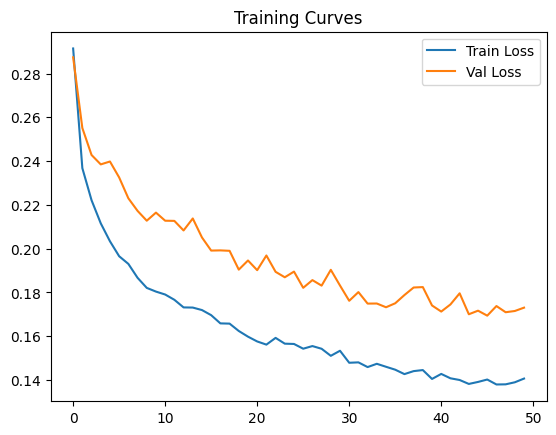

In [ ]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

max_epochs = 50
patience = 10
best_val_loss = float("inf")
early_stop_counter = 0

scaler = torch.amp.GradScaler(device="cuda")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

train_losses = []
val_losses = []

for epoch in range(1, max_epochs + 1):

    # -----------------------------
    # TRAIN
    # -----------------------------

    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{max_epochs}"):

        imgs = imgs.cuda()
        masks = masks.cuda()

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            preds = model(imgs)
            loss = combined_loss(preds, masks)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -----------------------------
    # VALIDATION
    # -----------------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.cuda()
            masks = masks.cuda()

            with torch.amp.autocast("cuda"):
                preds = model(imgs)
                loss = combined_loss(preds, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}/{max_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    scheduler.step(val_loss)

    # -----------------------------
    # SAVE BEST MODEL
    # -----------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0

        # Save weights only
        torch.save(model.state_dict(), "best_unet.pth")

        # Save full model (architecture + weights)
        torch.save(model, "best_unet.pt")

        print("🔥 Saved new best model")

    else:
        early_stop_counter += 1
        print(f"Early Stop Counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("⛔ Early stopping triggered")
        break

# -----------------------------
# PLOT CURVES
# -----------------------------
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training Curves")
plt.show()

In [ ]:
import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Same preprocessing as training
infer_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

def predict_mask(model, img_path, threshold=0.5):
    # Load image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply same transforms as training
    transformed = infer_transform(image=img_rgb)
    tensor = transformed["image"].unsqueeze(0).cuda()  # shape (1,3,256,256)

    # Predict
    with torch.no_grad():
        logits = model(tensor)          # raw logits
        probs = torch.sigmoid(logits)   # convert to probabilities
        pred = probs[0,0].cpu().numpy()

    # Binarize
    pred_bin = (pred > threshold).astype(np.float32)

    return img_rgb, pred_bin


In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---------------------------------------------------------
# 1. ALLOWLIST UNet CLASS (because it's defined in this notebook)
# ---------------------------------------------------------
from torch.serialization import add_safe_globals
add_safe_globals([UNet])   # UNet already defined above

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------
# 2. LOAD MODEL (best_unet.pt)
# ---------------------------------------------------------
model = torch.load(
    "cascadedDeepLearningForCancerCellDetectionAndClassification/best_unet.pt",
    map_location=device,
    weights_only=False
)
model.eval()

print("Model loaded successfully.")


# ---------------------------------------------------------
# 3. PREPROCESSING (same as validation)
# ---------------------------------------------------------
preprocess = A.Compose([
    A.Resize(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])


# ---------------------------------------------------------
# 4. PREDICT SINGLE MASK
# ---------------------------------------------------------
def predict_mask(model, img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    transformed = preprocess(image=img_rgb)
    tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)
        mask = (probs[0, 0].cpu().numpy() > 0.5).astype(np.uint8)

    return img_rgb, mask


# ---------------------------------------------------------
# 5. IoU METRIC
# ---------------------------------------------------------
def compute_iou(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return intersection / union


# ---------------------------------------------------------
# 6. DICE METRIC
# ---------------------------------------------------------
def compute_dice(pred, gt, smooth=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    dice = (2 * intersection + smooth) / (pred.sum() + gt.sum() + smooth)

    return dice


# ---------------------------------------------------------
# 7. EVALUATE TEST SET
# ---------------------------------------------------------
def evaluate_test_set(model, test_img_dir, test_mask_dir):
    test_images = sorted([
        f for f in os.listdir(test_img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    iou_scores = []
    dice_scores = []

    for img_name in test_images:

        img_path = os.path.join(test_img_dir, img_name)
        mask_path = os.path.join(test_mask_dir, img_name)

        # Load GT mask
        gt_mask = cv2.imread(mask_path, 0)
        gt_mask = (gt_mask > 0).astype(np.float32)

        # Predict 256×256
        img_rgb, pred_mask_256 = predict_mask(model, img_path)

        # Resize prediction back to original size
        pred_mask = cv2.resize(
            pred_mask_256,
            (gt_mask.shape[1], gt_mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        # Compute IoU + Dice
        iou = compute_iou(pred_mask, gt_mask)
        dice = compute_dice(pred_mask, gt_mask)

        iou_scores.append(iou)
        dice_scores.append(dice)

        # Plot
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("Original Image")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth Mask")
        plt.imshow(gt_mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title(f"Predicted Mask\nIoU={iou:.3f} | Dice={dice:.3f}")
        plt.imshow(pred_mask, cmap="gray")
        plt.axis("off")

        plt.suptitle(img_name, fontsize=14)
        plt.show()

    mean_iou = np.mean(iou_scores)
    mean_dice = np.mean(dice_scores)

    print(f"\n🔥 Mean IoU over {len(iou_scores)} test images: {mean_iou:.4f}")
    print(f"🔥 Mean Dice over {len(dice_scores)} test images: {mean_dice:.4f}")

    return mean_iou, mean_dice


# ---------------------------------------------------------
# 8. RUN EVALUATION
# ---------------------------------------------------------
mean_iou, mean_dice = evaluate_test_set(
    model,
    test_img_dir="unet_dataset/test/images",
    test_mask_dir="unet_dataset/test/masks"
)

print("Final Mean IoU:", mean_iou)
print("Final Mean Dice:", mean_dice)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_predicted_contour(img_rgb, pred_mask):
    """Draw GREEN contour for predicted mask."""
    img = img_rgb.copy()
    mask_uint8 = (pred_mask * 255).astype(np.uint8)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, (0,255,0), 2)  # GREEN
    return img

def draw_gt_contour(img_rgb, gt_mask):
    """Draw RED contour for ground truth mask."""
    img = img_rgb.copy()
    mask_uint8 = (gt_mask * 255).astype(np.uint8)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, (255,0,0), 2)  # RED
    return img


def evaluate_test_set_with_contours(model, test_img_dir, test_mask_dir):
    test_images = sorted([
        f for f in os.listdir(test_img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    iou_scores = []

    for img_name in test_images:
        img_path = os.path.join(test_img_dir, img_name)
        mask_path = os.path.join(test_mask_dir, img_name)

        # Load GT mask
        mask_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_gt = (mask_gt > 0).astype(np.float32)

        # Predict (256×256)
        img_rgb, pred_mask_256 = predict_mask(model, img_path)

        # Resize prediction back to original size
        pred_mask = cv2.resize(
            pred_mask_256,
            (mask_gt.shape[1], mask_gt.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        # Compute IoU
        iou = compute_iou(mask_gt, pred_mask)
        iou_scores.append(iou)

        # Draw contours
        pred_overlay = draw_predicted_contour(img_rgb, pred_mask)
        gt_overlay   = draw_gt_contour(img_rgb, mask_gt)

        # Combined overlay (GT red + Pred green)
        combined = img_rgb.copy()
        combined = draw_predicted_contour(combined, pred_mask)
        combined = draw_gt_contour(combined, mask_gt)

        # Show side-by-side
        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.title("Ground Truth Contour (RED)")
        plt.imshow(gt_overlay)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Predicted Contour (GREEN)")
        plt.imshow(pred_overlay)
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title(f"Overlay — IoU: {iou:.4f}")
        plt.imshow(combined)
        plt.axis("off")

        plt.suptitle(img_name, fontsize=14)
        plt.show()

    # -----------------------------
    # Mean IoU
    # -----------------------------
    mean_iou = np.mean(iou_scores)
    print(f"\n🔥 Mean IoU over {len(iou_scores)} images: {mean_iou:.4f}")

    return mean_iou


In [ ]:
evaluate_test_set_with_contours(
    model,
    test_img_dir="unet_dataset/test/images",
    test_mask_dir="unet_dataset/test/masks"
)

Output hidden; open in https://colab.research.google.com to view.

# **4) Classification**

In [ ]:
import os
import cv2
import numpy as np

path = "/content/drive/MyDrive/BUSI_Jpeg/"

DATASETS = [
    (path + "benign", path + "benign_mask", "benign"),
    (path + "malignant", path + "malignant_mask", "malignant")
]

OUT_IMG = "classification_dataset/images"
OUT_MASK = "classification_dataset/masks"
OUT_LABELS = "classification_dataset/labels.csv"

os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_MASK, exist_ok=True)

TARGET_SIZE = (256, 256)

def crop_by_bounding_box(image, mask):
    # Ensure binary mask
    _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None, None

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)

    cropped_img = image[y:y+h, x:x+w]
    cropped_mask = mask_bin[y:y+h, x:x+w]

    cropped_img = cv2.resize(cropped_img, TARGET_SIZE)
    cropped_mask = cv2.resize(cropped_mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

    return cropped_img, cropped_mask


with open(OUT_LABELS, "w") as f:
    f.write("filename,label\n")

    for img_folder, mask_folder, label in DATASETS:
        for filename in os.listdir(img_folder):
            if not filename.lower().endswith(".png"):
                continue

            img_path = os.path.join(img_folder, filename)

            # Correct BUSI mask naming
            mask_name = filename.replace(".png", "_mask.png")
            mask_path = os.path.join(mask_folder, mask_name)

            if not os.path.exists(mask_path):
                print("Mask not found for:", filename)
                continue

            image = cv2.imread(img_path)
            mask = cv2.imread(mask_path, 0)

            cropped_img, cropped_mask = crop_by_bounding_box(image, mask)
            if cropped_img is None:
                print("No contour found for:", filename)
                continue

            cv2.imwrite(os.path.join(OUT_IMG, filename), cropped_img)
            cv2.imwrite(os.path.join(OUT_MASK, filename), cropped_mask)

            f.write(f"{filename},{label}\n")

print("classification dataset created successfully!")

Cropped dataset created successfully!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("classification_dataset/labels.csv")

# First split: train vs temp (val+test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,   # 30% goes to val+test
    stratify=df["label"],
    random_state=42
)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,   # half of 30% → 15%
    stratify=temp_df["label"],
    random_state=42
)

train_df.to_csv("classification_dataset/train.csv", index=False)
val_df.to_csv("classification_dataset/val.csv", index=False)
test_df.to_csv("classification_dataset/test.csv", index=False)

print("Train/Val/Test split created!")


Train/Val/Test split created!


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
import pandas as pd

class TumorDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.label_map = {"benign": 0, "malignant": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["filename"])
        image = Image.open(img_path).convert("RGB")

        label = self.label_map[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = TumorDataset("classification_dataset/train.csv", "classification_dataset/images", train_tf)
val_dataset   = TumorDataset("classification_dataset/val.csv",   "classification_dataset/images", test_tf)
test_dataset  = TumorDataset("classification_dataset/test.csv",  "classification_dataset/images", test_tf)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
import torch.nn as nn
from torchvision import models
import torch

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final FC layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.cuda()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Epoch 1/50 | Train Loss: 0.0045 | Val Loss: 0.3304 | Train Acc: 1.0000 | Val Acc: 0.9175
🔥 Saved new best model
Epoch 2/50 | Train Loss: 0.0259 | Val Loss: 0.9982 | Train Acc: 0.9956 | Val Acc: 0.8866
Early Stop Counter: 1/7
Epoch 3/50 | Train Loss: 0.0327 | Val Loss: 0.2668 | Train Acc: 0.9845 | Val Acc: 0.9381
🔥 Saved new best model
Epoch 4/50 | Train Loss: 0.0598 | Val Loss: 0.4101 | Train Acc: 0.9934 | Val Acc: 0.9278
Early Stop Counter: 1/7
Epoch 5/50 | Train Loss: 0.0239 | Val Loss: 0.3823 | Train Acc: 0.9956 | Val Acc: 0.9072
Early Stop Counter: 2/7
Epoch 6/50 | Train Loss: 0.0228 | Val Loss: 0.6518 | Train Acc: 0.9912 | Val Acc: 0.8969
Early Stop Counter: 3/7
Epoch 7/50 | Train Loss: 0.0252 | Val Loss: 0.4413 | Train Acc: 0.9912 | Val Acc: 0.9175
Early Stop Counter: 4/7
Epoch 8/50 | Train Loss: 0.0067 | Val Loss: 0.2343 | Train Acc: 0.9978 | Val Acc: 0.9175
🔥 Saved new best model
Epoch 9/50 | Train Loss: 0.0090 | Val Loss: 0.2790 | Train Acc: 0.9956 | Val Acc: 0.9381
Early Stop

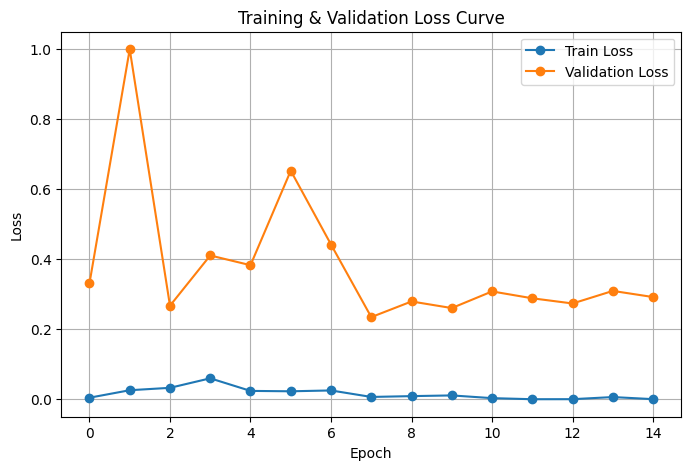

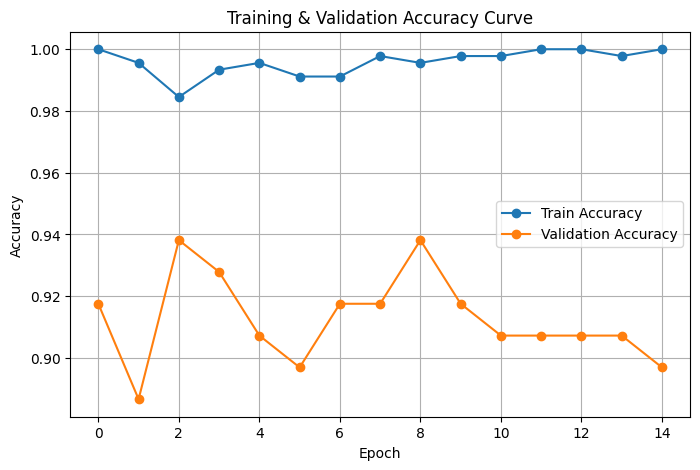

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# Stopping Mechanisms
# -----------------------------
patience = 7
best_val_loss = float("inf")
early_stop_counter = 0

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

EPOCHS = 50

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Optional but recommended
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = train_correct / len(train_dataset)
    train_accs.append(train_acc)

    # -----------------------------
    # VALIDATION
    # -----------------------------
    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.cuda(), labels.cuda()
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = val_correct / len(val_dataset)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # -----------------------------
    # LR Scheduler Step
    # -----------------------------
    scheduler.step(avg_val_loss)

    # -----------------------------
    # EARLY STOPPING + SAVE BEST MODEL
    # -----------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0

        torch.save(model.state_dict(), "final_best_resnet18_classifier.pt")
        print("🔥 Saved new best model")
    else:
        early_stop_counter += 1
        print(f"Early Stop Counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print("⛔ Early stopping triggered")
            break

# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy", marker='o')
plt.plot(val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()
